In [1]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas matplotlib seaborn -q

import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.4.6
pandas: 3.0.3


In [2]:
# ─────────────────────────────────────────────
# 모두마켓 데이터 생성 — 이 셀 하나로 오늘 쓸 데이터가 모두 준비됩니다.
# (실제 현장처럼 '텍스트·날짜 오염'을 일부러 심어 둡니다)
# ─────────────────────────────────────────────
np.random.seed(42)

# 1) 고객(customers) -------------------------------------------------
n_customers = 200
last_names = ["김", "이", "박", "최", "정", "강", "조", "윤", "장", "임"]
first_names = ["민준", "서연", "도윤", "지우", "하준", "서윤", "예준", "지유", "주원", "지호"]
names = [np.random.choice(last_names) + np.random.choice(first_names) for _ in range(n_customers)]
# 이름 일부에 앞뒤 공백 오염
for i in np.random.choice(n_customers, 15, replace=False):
    names[i] = "  " + names[i] + " "

# 이메일: 대소문자 + 앞뒤 공백 오염
domains = ["gmail.com", "naver.com", "MODUMARKET.com", "daum.net", "kakao.com"]
emails = []
for i in range(n_customers):
    e = f"user{i+1:03d}@{np.random.choice(domains)}"
    r = np.random.random()
    if r < 0.20:
        e = e.upper()              # 전체 대문자
    elif r < 0.35:
        e = "  " + e + " "         # 앞뒤 공백
    emails.append(e)

# 전화번호: 네 가지 형식 혼재
def make_phone(i):
    mid, end = np.random.randint(1000, 9999), np.random.randint(1000, 9999)
    fmt = i % 4
    if fmt == 0:
        return f"010-{mid}-{end}"
    if fmt == 1:
        return f"010{mid}{end}"
    if fmt == 2:
        return f"010.{mid}.{end}"
    return f"+82 10 {mid} {end}"
phones = [make_phone(i) for i in range(n_customers)]

# 지역: 표기 혼재(공백·영문)
region = np.random.choice(
    ["서울", " 서울 ", "Seoul", "경기", "부산", "인천", "대구"],
    n_customers, p=[0.30, 0.05, 0.05, 0.25, 0.15, 0.10, 0.10])

# 가입일: 네 가지 날짜 포맷 혼재(문자열로 저장)
signup_base = pd.to_datetime("2024-01-01") + pd.to_timedelta(np.random.randint(0, 365, n_customers), unit="D")
signup = []
for i, d in enumerate(signup_base):
    f = i % 4
    if f == 0:
        signup.append(d.strftime("%Y-%m-%d"))
    elif f == 1:
        signup.append(d.strftime("%Y/%m/%d"))
    elif f == 2:
        signup.append(d.strftime("%Y.%m.%d"))
    else:
        signup.append(d.strftime("%Y%m%d"))

customers = pd.DataFrame({
    "customer_id": [f"C{i+1:04d}" for i in range(n_customers)],
    "name": names,
    "email": emails,
    "phone": phones,
    "region": region,
    "signup_date": signup,
})

# 2) 주문(orders) ----------------------------------------------------
catalog = [("무선 이어폰", "P-1001", 89000), ("블루투스 스피커", "P-1002", 49000),
           ("노트북 거치대", "P-1003", 29000), ("기계식 키보드", "P-1004", 119000),
           ("USB-C 충전기", "P-1005", 19000), ("보조배터리", "P-1006", 39000),
           ("스마트워치", "P-1007", 159000), ("액션캠", "P-1008", 229000)]
n_orders = 2000
pick = np.random.randint(0, len(catalog), n_orders)

product_name, amount = [], []
for j in pick:
    name, codeid, price = catalog[j]
    label = f"{name} ({codeid})"
    r = np.random.random()
    if r < 0.18:
        label = "  " + label + "  "        # 앞뒤 공백
    elif r < 0.30:
        label = label.replace(" ", "  ")    # 단어 사이 이중 공백
    product_name.append(label)
    amount.append(price * np.random.choice([1, 1, 1, 2, 3]))

coupon = np.random.choice(
    ["SALE2025", "WELCOME10", "VIP-2025", "summer25", "FREESHIP", ""],
    n_orders, p=[0.18, 0.15, 0.10, 0.10, 0.07, 0.40])

channel = np.random.choice(["web", "app", "app ", "APP"], n_orders, p=[0.45, 0.45, 0.05, 0.05])

# 주문 일시: 두 가지 포맷 혼재 + 소수의 오류값
dt_base = pd.to_datetime("2025-01-01") + pd.to_timedelta(np.random.randint(0, 90 * 24 * 3600, n_orders), unit="s")
order_datetime = []
for i, d in enumerate(dt_base):
    if i % 2 == 0:
        order_datetime.append(d.strftime("%Y-%m-%d %H:%M:%S"))
    else:
        order_datetime.append(d.strftime("%Y/%m/%d %H:%M:%S"))
# 오류값 심기: 파싱 불가능한 문자열 12건
for i in np.random.choice(n_orders, 12, replace=False):
    order_datetime[i] = np.random.choice(["처리중", "-", "unknown"])

orders = pd.DataFrame({
    "order_id": [f"O{i+1:05d}" for i in range(n_orders)],
    "customer_id": np.random.choice(customers["customer_id"], n_orders),
    "product_name": product_name,
    "amount": amount,
    "coupon": coupon,
    "channel": channel,
    "order_datetime": order_datetime,
})

print("모두마켓 데이터 생성 완료")
print("customers:", customers.shape, "| orders:", orders.shape)

모두마켓 데이터 생성 완료
customers: (200, 6) | orders: (2000, 7)


In [3]:
# 데이터가 어떻게 '오염'되어 있는지 맨 위 몇 줄을 직접 봅니다.
print("=== customers (고객) ===")
display(customers.head())
print("\n=== orders (주문) ===")
display(orders.head())

=== customers (고객) ===


,customer_id,name,email,phone,region,signup_date
0,C0001,조지우,user001@daum.net,010-8973-9577,경기,2024-04-27
1,C0002,윤하준,user002@gmail.com,01090709666,서울,2024/09/26
2,C0003,조지호,USER003@NAVER.COM,010.9609.7490,서울,2024.03.20
3,C0004,박예준,USER004@KAKAO.COM,+82 10 4600 7783,인천,20240402
4,C0005,윤하준,USER005@KAKAO.COM,010-5971-2205,대구,2024-09-22



=== orders (주문) ===


,order_id,customer_id,product_name,amount,coupon,channel,order_datetime
0,O00001,C0131,무선 이어폰 (P-1001),89000,FREESHIP,app,2025-01-01 23:12:56
1,O00002,C0094,USB-C 충전기 (P-1005),57000,WELCOME10,web,2025/01/25 12:15:09
2,O00003,C0008,기계식 키보드 (P-1004),357000,,web,2025-01-31 14:14:25
3,O00004,C0086,블루투스 스피커 (P-1002),147000,,app,2025/03/30 02:12:54
4,O00005,C0089,무선 이어폰 (P-1001),89000,,web,2025-02-18 23:06:24


In [5]:
# 예제: 정제 전 — region을 그냥 세면 같은 서울이 쪼개진다
print("[정제 전] region 값의 종류")
print(customers["region"].value_counts())
# repr로 보면 숨은 공백이 보입니다.
print("\n숨은 공백 확인:", [repr(x) for x in customers["region"].unique()])

[정제 전] region 값의 종류
region
경기       61
서울       52
부산       32
인천       19
대구       18
Seoul    10
 서울       8
Name: count, dtype: int64

숨은 공백 확인: ["'경기'", "'서울'", "'인천'", "'대구'", "'부산'", "'Seoul'", "' 서울 '"]


In [6]:
# 예제: strip → lower → replace 3단계로 region 통일하기
clean_region = (
    customers["region"]
    .str.strip()                      # 1) 앞뒤 공백 제거
    .str.replace("Seoul", "서울")      # 2) 영문 표기를 한글로 치환
)
customers["region_clean"] = clean_region

print("[정제 후] region_clean 값의 종류")
print(customers["region_clean"].value_counts())

[정제 후] region_clean 값의 종류
region_clean
서울    70
경기    61
부산    32
인천    19
대구    18
Name: count, dtype: int64


In [7]:
# 예제: 이메일 정제 — 앞뒤 공백 제거 + 소문자 통일
print("[정제 전] 이메일 일부(repr로 공백 노출)")
print([repr(x) for x in customers["email"].head(6)])

customers["email_clean"] = customers["email"].str.strip().str.lower()

print("\n[정제 후]")
print(customers["email_clean"].head(6).tolist())

[정제 전] 이메일 일부(repr로 공백 노출)
["'  user001@daum.net '", "'  user002@gmail.com '", "'USER003@NAVER.COM'", "'USER004@KAKAO.COM'", "'USER005@KAKAO.COM'", "'user006@kakao.com'"]

[정제 후]
['user001@daum.net', 'user002@gmail.com', 'user003@naver.com', 'user004@kakao.com', 'user005@kakao.com', 'user006@kakao.com']


In [8]:
print("[정제 전]")
print(orders["channel"].value_counts())

orders["channel_clean"] = orders["channel"].str.strip().str.lower()
print("\n[정제 후]")
print(orders["channel_clean"].value_counts())


[정제 전]
channel
web     919
app     902
app      98
APP      81
Name: count, dtype: int64

[정제 후]
channel_clean
app    1081
web     919
Name: count, dtype: int64


In [9]:
# 예제: replace로 전화번호에서 숫자만 남기기 (숫자가 아닌 모든 글자 삭제)
# [^0-9] = '숫자가 아닌' 글자, 이것을 빈 문자열로 치환 → 숫자만 남음
customers["phone_digits"] = customers["phone"].str.replace(r"[^0-9]", "", regex=True)

print("[정제 전 → 후]")
for before, after in zip(customers["phone"].head(4), customers["phone_digits"].head(4)):
    print(f"{before:<18} →  {after}")

[정제 전 → 후]
010-8973-9577      →  01089739577
01090709666        →  01090709666
010.9609.7490      →  01096097490
+82 10 4600 7783   →  821046007783


In [10]:
# 예제: extract로 상품명에서 상품 코드(P-숫자)만 뽑기
# 패턴 (P-\d+) = 'P-' 다음에 숫자가 1개 이상 → 괄호로 묶어 그 부분만 추출
orders["product_code"] = orders["product_name"].str.extract(r"(P-\d+)")

print(orders[["product_name", "product_code"]].head(6))

            product_name product_code
0      무선 이어폰 (P-1001)         P-1001
1     USB-C 충전기 (P-1005)       P-1005
2       기계식 키보드 (P-1004)       P-1004
3    블루투스 스피커 (P-1002)         P-1002
4        무선 이어폰 (P-1001)       P-1001
5         보조배터리 (P-1006)       P-1006


In [11]:
# 예제: findall로 쿠폰 코드의 '영문 대문자 묶음'과 '숫자 묶음' 분리해 보기
sample = pd.Series(["SALE2025", "WELCOME10", "VIP-2025", "summer25", ""])

print("대문자 알파벳 덩어리 찾기  [A-Z]+ :")
print(sample.str.findall(r"[A-Z]+").tolist())
print("\n숫자 덩어리 찾기  \\d+ :")
print(sample.str.findall(r"\d+").tolist())

대문자 알파벳 덩어리 찾기  [A-Z]+ :
[['SALE'], ['WELCOME'], ['VIP'], [], []]

숫자 덩어리 찾기  \d+ :
[['2025'], ['10'], ['2025'], ['25'], []]


In [12]:
# 1) 쿠폰에서 숫자만 추출
orders["coupon_num"] = orders["coupon"].str.extract(r"(\d+)")
print(orders[["coupon", "coupon_num"]].head(8))

# 2) 전화번호 자릿수 분포
print(customers["phone_digits"].str.len().value_counts())


      coupon coupon_num
0   FREESHIP        NaN
1  WELCOME10         10
2                   NaN
3                   NaN
4                   NaN
5  WELCOME10         10
6                   NaN
7   SALE2025       2025
phone_digits
11    150
12     50
Name: count, dtype: int64


In [15]:
# 예제: replace로 전화번호에서 숫자만 남기기 (숫자가 아닌 모든 글자 삭제)
# [^0-9] = '숫자가 아닌' 글자, 이것을 빈 문자열로 치환 → 숫자만 남음
customers["phone_digits"] = customers["phone"].str.replace(r"[^0-9]", "", regex=True)

print("[정제 전 → 후]")
for before, after in zip(customers["phone"].head(4), customers["phone_digits"].head(4)):
    print(f"{before:<18} →  {after}")

[정제 전 → 후]
010-8973-9577      →  01089739577
01090709666        →  01090709666
010.9609.7490      →  01096097490
+82 10 4600 7783   →  821046007783


In [16]:
# 예제: extract로 상품명에서 상품 코드(P-숫자)만 뽑기
# 패턴 (P-\d+) = 'P-' 다음에 숫자가 1개 이상 → 괄호로 묶어 그 부분만 추출
orders["product_code"] = orders["product_name"].str.extract(r"(P-\d+)")

print(orders[["product_name", "product_code"]].head(6))

            product_name product_code
0      무선 이어폰 (P-1001)         P-1001
1     USB-C 충전기 (P-1005)       P-1005
2       기계식 키보드 (P-1004)       P-1004
3    블루투스 스피커 (P-1002)         P-1002
4        무선 이어폰 (P-1001)       P-1001
5         보조배터리 (P-1006)       P-1006


In [17]:
# 예제: findall로 쿠폰 코드의 '영문 대문자 묶음'과 '숫자 묶음' 분리해 보기
sample = pd.Series(["SALE2025", "WELCOME10", "VIP-2025", "summer25", ""])

print("대문자 알파벳 덩어리 찾기  [A-Z]+ :")
print(sample.str.findall(r"[A-Z]+").tolist())
print("\n숫자 덩어리 찾기  \\d+ :")
print(sample.str.findall(r"\d+").tolist())

대문자 알파벳 덩어리 찾기  [A-Z]+ :
[['SALE'], ['WELCOME'], ['VIP'], [], []]

숫자 덩어리 찾기  \d+ :
[['2025'], ['10'], ['2025'], ['25'], []]


In [20]:
orders["order_dt"] = pd.to_datetime(orders["order_datetime"], errors="coerce")


In [21]:
print("가장 이른 주문일:", orders["order_dt"].min())
print("가장 늦은 주문일:", orders["order_dt"].max())


가장 이른 주문일: 2025-01-01 00:36:15
가장 늦은 주문일: 2025-03-31 23:20:27


In [22]:
failed = orders[orders["order_dt"].isna()]
print(failed[["order_datetime", "order_dt"]])


           order_datetime order_dt
1     2025/01/25 12:15:09      NaT
3     2025/03/30 02:12:54      NaT
5     2025/02/18 07:41:05      NaT
7     2025/03/04 20:49:09      NaT
9     2025/02/24 06:15:48      NaT
...                   ...      ...
1991  2025/01/08 18:19:34      NaT
1993  2025/01/14 15:00:09      NaT
1995  2025/01/20 13:27:25      NaT
1997  2025/01/04 14:28:14      NaT
1999  2025/01/19 16:19:15      NaT

[1006 rows x 2 columns]


In [23]:
print(orders["order_datetime"].head(10))


0    2025-01-01 23:12:56
1    2025/01/25 12:15:09
2    2025-01-31 14:14:25
3    2025/03/30 02:12:54
4    2025-02-18 23:06:24
5    2025/02/18 07:41:05
6    2025-02-15 11:20:31
7    2025/03/04 20:49:09
8    2025-01-23 21:14:07
9    2025/02/24 06:15:48
Name: order_datetime, dtype: str


In [24]:
# 하이픈 포맷과 슬래시 포맷을 각각 시도한 뒤 합치기
dt1 = pd.to_datetime(orders["order_datetime"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
dt2 = pd.to_datetime(orders["order_datetime"], format="%Y/%m/%d %H:%M:%S", errors="coerce")

orders["order_dt"] = dt1.fillna(dt2)

# 다시 확인
failed = orders[orders["order_dt"].isna()]
print(f"파싱 실패 건수: {len(failed)}")
print(failed[["order_datetime", "order_dt"]])


파싱 실패 건수: 12
     order_datetime order_dt
100               -      NaT
173               -      NaT
314             처리중      NaT
383             처리중      NaT
421         unknown      NaT
424         unknown      NaT
530         unknown      NaT
589               -      NaT
778             처리중      NaT
1241        unknown      NaT
1442            처리중      NaT
1769              -      NaT


In [25]:
print("가장 이른 주문일:", orders["order_dt"].min())
print("가장 늦은 주문일:", orders["order_dt"].max())


가장 이른 주문일: 2025-01-01 00:36:15
가장 늦은 주문일: 2025-03-31 23:20:27


In [26]:
# 예제: 날짜에서 부품 꺼내 새 컬럼 만들기
valid = orders.dropna(subset=["order_dt"]).copy()   # NaT(파싱 실패) 제외

valid["year"] = valid["order_dt"].dt.year
valid["month"] = valid["order_dt"].dt.month
valid["hour"] = valid["order_dt"].dt.hour
valid["dow_num"] = valid["order_dt"].dt.dayofweek      # 0=월 ... 6=일
valid["dow_name"] = valid["order_dt"].dt.day_name()    # 영문 요일 이름

print(valid[["order_dt", "year", "month", "hour", "dow_num", "dow_name"]].head())

             order_dt  year  month  hour  dow_num   dow_name
0 2025-01-01 23:12:56  2025      1    23        2  Wednesday
1 2025-01-25 12:15:09  2025      1    12        5   Saturday
2 2025-01-31 14:14:25  2025      1    14        4     Friday
3 2025-03-30 02:12:54  2025      3     2        6     Sunday
4 2025-02-18 23:06:24  2025      2    23        1    Tuesday


In [30]:
# 예제: 부품 + groupby = '요일별 평균 매출' (D+004 복습과 결합)
dow_sales = valid.groupby("dow_name")["amount"].mean()

# 요일 순서를 월→일로 정렬 (영문 이름 순서 지정)
order_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_sales = dow_sales.reindex(order_days)

print("[요일별 평균 주문 금액]")
print(dow_sales.round(0))

[요일별 평균 주문 금액]
dow_name
Monday       162151.0
Tuesday      141141.0
Wednesday    137615.0
Thursday     157082.0
Friday       156325.0
Saturday     135774.0
Sunday       130071.0
Name: amount, dtype: float64


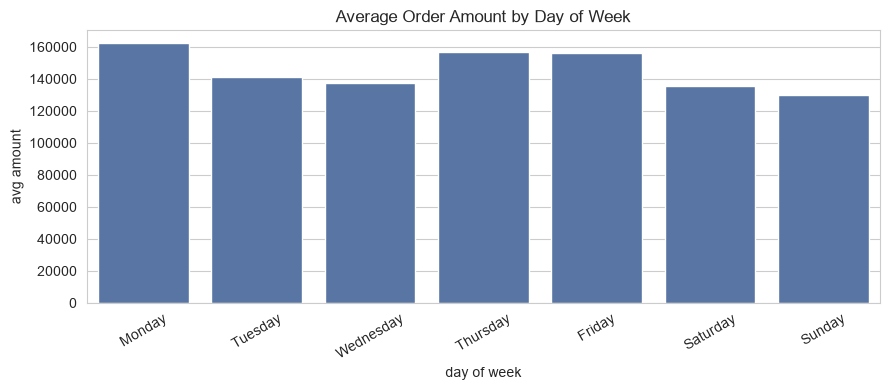

In [31]:
# [도식] 요일별 평균 매출 막대그래프 — 부품이 곧 인사이트가 된다
plt.figure(figsize=(9, 4))
sns.barplot(x=dow_sales.index, y=dow_sales.values, color="#4C72B0")
plt.title("Average Order Amount by Day of Week")
plt.xlabel("day of week"); plt.ylabel("avg amount")
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

In [32]:
valid = orders.dropna(subset=["order_dt"]).copy()  # NaT 12건 제외
valid["year"] = valid["order_dt"].dt.year
valid["month"] = valid["order_dt"].dt.month
valid["hour"] = valid["order_dt"].dt.hour
valid["dow_num"] = valid["order_dt"].dt.dayofweek   # 0=월 ... 6=일
valid["dow_name"] = valid["order_dt"].dt.day_name()


In [33]:
dow_sales = valid.groupby("dow_name")["amount"].mean()


In [34]:
# 예제: 일별 매출 합계 (resample 'D')
ts = valid.set_index("order_dt").sort_index()   # 날짜를 인덱스로 + 시간순 정렬

daily_sales = ts["amount"].resample("D").sum()   # 하루 단위 합계
print("일별 매출 (앞 7일):")
print(daily_sales.head(7))
print("\n총 일수:", len(daily_sales))

일별 매출 (앞 7일):
order_dt
2025-01-01    2364000
2025-01-02    3206000
2025-01-03    2079000
2025-01-04    2810000
2025-01-05    2468000
2025-01-06    2994000
2025-01-07    3373000
Freq: D, Name: amount, dtype: int64

총 일수: 90


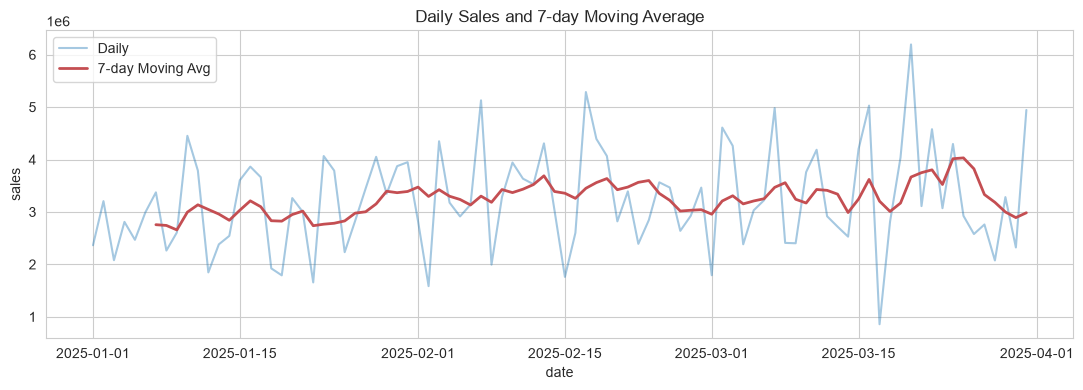

In [35]:
# 예제: 이동평균(rolling) — 들쭉날쭉한 일 매출을 7일 평균으로 부드럽게
daily_ma7 = daily_sales.rolling(7).mean()        # 최근 7일 이동평균

plt.figure(figsize=(11, 4))
plt.plot(daily_sales.index, daily_sales.values, alpha=0.4, label="Daily")
plt.plot(daily_ma7.index, daily_ma7.values, color="#C44E52", linewidth=2, label="7-day Moving Avg")
plt.title("Daily Sales and 7-day Moving Average")
plt.xlabel("date"); plt.ylabel("sales")
plt.legend()
plt.tight_layout(); plt.show()

In [36]:
# 예제: 주 단위로 자를 바꿔보기 (resample 'W')
weekly_sales = ts["amount"].resample("W").sum()
print("[주별 매출]")
print(weekly_sales)

[주별 매출]
order_dt
2025-01-05    12927000
2025-01-12    21327000
2025-01-19    19767000
2025-01-26    20837000
2025-02-02    23068000
2025-02-09    23986000
2025-02-16    22812000
2025-02-23    25194000
2025-03-02    22460000
2025-03-09    22691000
2025-03-16    25338000
2025-03-23    24663000
2025-03-30    20239000
2025-04-06     4945000
Freq: W-SUN, Name: amount, dtype: int64


In [37]:
# 1) 시간대별 주문 건수
hourly = ts["amount"].resample("h").count()
print(hourly.head(24))

# 2) 3일 이동평균 vs 7일 이동평균
ma3 = daily_sales.rolling(3).mean()
print(pd.DataFrame({"daily": daily_sales, "ma3": ma3, "ma7": daily_ma7}).head(10))


order_dt
2025-01-01 00:00:00    2
2025-01-01 01:00:00    0
2025-01-01 02:00:00    1
2025-01-01 03:00:00    0
2025-01-01 04:00:00    2
2025-01-01 05:00:00    1
2025-01-01 06:00:00    1
2025-01-01 07:00:00    3
2025-01-01 08:00:00    0
2025-01-01 09:00:00    0
2025-01-01 10:00:00    0
2025-01-01 11:00:00    2
2025-01-01 12:00:00    0
2025-01-01 13:00:00    0
2025-01-01 14:00:00    1
2025-01-01 15:00:00    1
2025-01-01 16:00:00    1
2025-01-01 17:00:00    0
2025-01-01 18:00:00    0
2025-01-01 19:00:00    0
2025-01-01 20:00:00    2
2025-01-01 21:00:00    1
2025-01-01 22:00:00    1
2025-01-01 23:00:00    1
Freq: h, Name: amount, dtype: int64
              daily           ma3           ma7
order_dt                                       
2025-01-01  2364000           NaN           NaN
2025-01-02  3206000           NaN           NaN
2025-01-03  2079000  2.549667e+06           NaN
2025-01-04  2810000  2.698333e+06           NaN
2025-01-05  2468000  2.452333e+06           NaN
2025-01-06  2994000

In [38]:
# 웹 서버 접속 로그 생성 (가상) — 한 줄이 통째로 문자열
np.random.seed(7)
n_logs = 1500
ips = [f"203.0.113.{k}" for k in range(1, 60)] + [f"198.51.100.{k}" for k in range(1, 60)]
paths = ["/", "/products", "/products/123", "/products/456", "/cart",
         "/checkout", "/login", "/search", "/api/orders"]
methods = ["GET", "GET", "GET", "POST"]
statuses = [200, 200, 200, 200, 200, 404, 500, 301]

# 시각: 7일치, 초 단위로 무작위 발생 후 정렬
log_times = pd.to_datetime("2025-03-01") + pd.to_timedelta(
    np.sort(np.random.randint(0, 7 * 24 * 3600, n_logs)), unit="s")

lines = []
for i in range(n_logs):
    ip = np.random.choice(ips)
    ts_str = log_times[i].strftime("%d/%b/%Y:%H:%M:%S")   # 12/Jan/2025:10:15:32
    m = np.random.choice(methods)
    p = np.random.choice(paths)
    st = np.random.choice(statuses)
    sz = np.random.randint(200, 5000)
    lines.append(f'{ip} - - [{ts_str}] "{m} {p} HTTP/1.1" {st} {sz}')

web_logs = pd.DataFrame({"raw": lines})
print("웹 로그 생성 완료:", web_logs.shape)
print("\n[원본 로그 한 줄은 이렇게 생겼습니다]")
for line in web_logs["raw"].head(3):
    print(line)

웹 로그 생성 완료: (1500, 1)

[원본 로그 한 줄은 이렇게 생겼습니다]
203.0.113.39 - - [01/Mar/2025:00:01:14] "GET / HTTP/1.1" 200 2371
198.51.100.21 - - [01/Mar/2025:00:02:24] "GET / HTTP/1.1" 301 284
198.51.100.17 - - [01/Mar/2025:00:02:28] "GET /search HTTP/1.1" 200 1448


In [39]:
# 시나리오 1 — 정규식으로 6개 필드를 한 번에 추출
pattern = (
    r"(?P<ip>\d+\.\d+\.\d+\.\d+)"        # IP: 숫자.숫자.숫자.숫자
    r" - - \["                            # 고정 구분 부분
    r"(?P<ts>[^\]]+)"                     # 시각: ] 가 아닌 글자들
    r"\] \""                              # ] 와 따옴표
    r"(?P<method>\w+) "                   # 방식: GET/POST
    r"(?P<path>\S+)"                      # 경로: 공백 아닌 글자들
    r"[^\"]*\" "                          # HTTP/1.1 부분 건너뛰기
    r"(?P<status>\d+) "                   # 상태 코드
    r"(?P<size>\d+)"                      # 응답 크기
)
logs = web_logs["raw"].str.extract(pattern)
print("추출된 표:", logs.shape)
print(logs.head())
print("\n추출 실패(어느 한 칸이라도 NaN) 행 수:", logs.isna().any(axis=1).sum())

추출된 표: (1500, 6)
              ip                    ts method       path status  size
0   203.0.113.39  01/Mar/2025:00:01:14    GET          /    200  2371
1  198.51.100.21  01/Mar/2025:00:02:24    GET          /    301   284
2  198.51.100.17  01/Mar/2025:00:02:28    GET    /search    200  1448
3   203.0.113.35  01/Mar/2025:00:03:56    GET      /cart    404  3921
4   203.0.113.47  01/Mar/2025:00:14:29    GET  /products    500  2580

추출 실패(어느 한 칸이라도 NaN) 행 수: 0


In [46]:
# 시나리오 2 — 타입 정리(날짜·숫자) + dt 부품
logs["ts"] = pd.to_datetime(logs["ts"], format="%d/%b/%Y:%H:%M:%S", errors="coerce")
logs["status"] = logs["status"].astype(int)
logs["size"] = logs["size"].astype(int)

# dt 부품: 시각(hour)과 요일
logs["hour"] = logs["ts"].dt.hour
logs["dow_name"] = logs["ts"].dt.day_name()

print("정리 후 자료형:")
print(logs.dtypes)
print()
print(logs[["ip", "ts", "method", "path", "status", "hour", "dow_name"]].head())

정리 후 자료형:
ip                     str
ts          datetime64[us]
method                 str
path                   str
status               int64
size                 int64
hour                 int32
dow_name               str
dtype: object

              ip                  ts method       path  status  hour  dow_name
0   203.0.113.39 2025-03-01 00:01:14    GET          /     200     0  Saturday
1  198.51.100.21 2025-03-01 00:02:24    GET          /     301     0  Saturday
2  198.51.100.17 2025-03-01 00:02:28    GET    /search     200     0  Saturday
3   203.0.113.35 2025-03-01 00:03:56    GET      /cart     404     0  Saturday
4   203.0.113.47 2025-03-01 00:14:29    GET  /products     500     0  Saturday


In [45]:
# 시나리오 2 — 상태 코드·인기 경로 빠르게 집계
print("[상태 코드 분포]")
print(logs["status"].value_counts())

error_rate = (logs["status"] >= 400).mean() * 100   # 4xx·5xx 비율
print(f"\n오류 응답(4xx·5xx) 비율: {error_rate:.1f}%")

print("\n[요청이 많은 경로 TOP 5]")
print(logs["path"].value_counts().head())

[상태 코드 분포]
status
200    964
301    188
404    178
500    170
Name: count, dtype: int64

오류 응답(4xx·5xx) 비율: 23.2%

[요청이 많은 경로 TOP 5]
path
/                184
/search          175
/cart            173
/products/456    171
/products        168
Name: count, dtype: int64


In [44]:
# 코드 퀴즈 — 모범 답안
# 1) 정제(strip+lower) → 2) @ 뒤 도메인 추출 → 3) 조건 집계
clean = customers["email"].str.strip().str.lower()
domain = clean.str.split("@").str[1]
gmail_count = (domain == "gmail.com").sum()

print("gmail.com 고객 수:", gmail_count)

gmail.com 고객 수: 39


In [43]:
clean = customers["email"].str.strip().str.lower()   # 1) 정제
domain = clean.str.split("@").str[1]                   # 2) @ 뒤 도메인 추출
gmail_count = (domain == "gmail.com").sum()             # 3) 조건 집계


In [47]:
ip_counts = logs["ip"].value_counts()
print(ip_counts.head(10))


ip
198.51.100.41    24
203.0.113.58     21
198.51.100.52    19
203.0.113.27     19
203.0.113.18     19
203.0.113.35     18
198.51.100.24    18
198.51.100.28    18
203.0.113.56     18
203.0.113.16     18
Name: count, dtype: int64


In [49]:
# 1) 기간 확인
print(logs["ts"].min(), "~", logs["ts"].max())

# 2) 트래픽 몰린 시간대
print(logs["hour"].value_counts().head(5))


2025-03-01 00:01:14 ~ 2025-03-07 23:42:41
hour
22    82
1     81
7     81
11    76
19    72
Name: count, dtype: int64


# 모두마켓 웹 트래픽 - 로그 분석 리포트

## 1. 데이터 개요
- 로그 줄 수: 1500줄
- 기간: 2025-03-01 ~ 2025-03-07
- 추출 필드: ip, ts, method, path, status, size

## 2. 파싱 (어떻게 표로 만들었나)
- 사용한 정규식 패턴의 핵심: IP는 `\d+\.\d+\...`, 시각은 `[^\]]+` 로 추출
- 날짜 형식: %d/%b/%Y:%H:%M:%S 로 파싱, 실패 0건

## 3. 트래픽 요약
- 총 요청 수: 1500
- 오류 응답(4xx·5xx) 비율: 23.2%
- 요청 많은 경로 TOP 3: / (184), /search (175), /cart (173)

## 4. 시간 패턴 (리샘플링에서 읽은 것)
- 트래픽이 가장 몰린 시간대: 22시 (82건)
- 요일/시간대 특징: 22시, 1시, 7시, 11시, 19시대에 상대적으로 요청이 몰림. 특히 22시(밤 10시)가 가장 많고, 심야(1시)와 이른 오전(7시)에도 눈에 띄게 높아 이용 시간대가 낮보다 야간·이른 아침에 분산된 경향

## 5. 다음 분석 제안
- 오류 응답 비율이 23.2%로 다소 높으므로, 4xx·5xx가 잦은 경로(/products/456, /products 등)를 우선 점검할 필요가 있음
- IP별 요청 수는 18~24건으로 고르게 분포해 비정상 IP는 발견되지 않았으나, 22시·심야 시간대 트래픽 급증 원인(정상 사용자 패턴 vs 자동화 트래픽)을 추가로 확인할 필요가 있음


<Axes: title={'center': 'Hourly Request Count'}, xlabel='ts'>

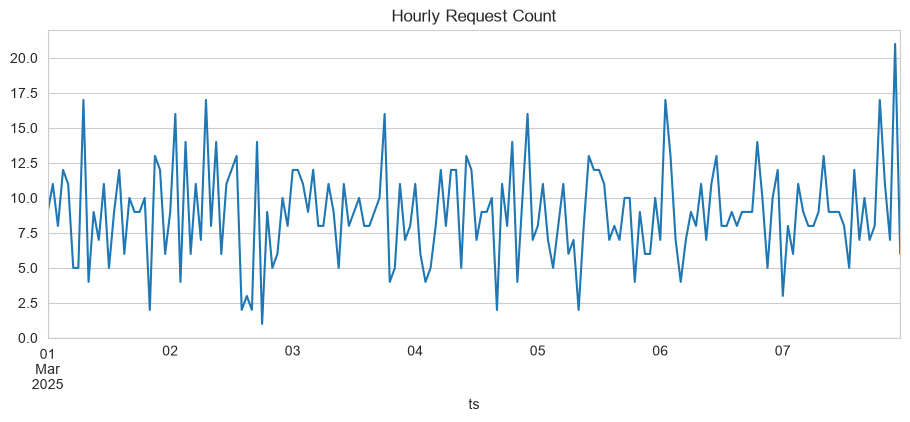

In [53]:
hourly_logs = logs.set_index("ts")["status"].resample("h").count()
hourly_logs.plot(figsize=(11,4), title="Hourly Request Count")


In [54]:
error_paths = logs[logs["status"] >= 400]["path"].value_counts()
print(error_paths.head(5))


path
/checkout        45
/                44
/cart            43
/products/456    43
/api/orders      40
Name: count, dtype: int64


## 5. 다음 분석 제안
- 오류가 가장 잦은 경로는 /checkout(45건)이며, /cart(43건)와 함께 결제 관련 경로가 상위권을 차지함 → 결제 프로세스 자체의 안정성 점검을 운영팀에 우선 제안
- IP별 요청 수는 18~24건으로 고르게 분포해 비정상 IP는 발견되지 않았음
- 시간대별 요청은 뚜렷한 패턴 없이 0~20건 사이 변동, 22시경 다소 높은 편이나 추가 관찰 필요
